In [1]:
# ========== 环境准备 ==========
import warnings                          # 导入警告控制模块
warnings.filterwarnings('ignore')        # 隐藏不影响学习的警告

import numpy as np                       # 数值计算（数组、随机数、统计）
import pandas as pd                      # 表格数据处理（像 Excel）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）
import yfinance as yf                    # 从雅虎财经下载行情（需联网）

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

TICKER = 'AAPL'      # 策略交易哪只股票
BENCHMARK = 'SPY'    # 大盘对比用标普500 ETF
PERIOD = '2y'        # 回测样本长度

print('环境就绪 ✓')                       # 提示：环境加载完成


环境就绪 ✓


In [2]:
# ========== 第1步：下载数据并算双均线 ==========
raw = yf.download(TICKER, period=PERIOD, progress=False, multi_level_index=False)  # 下载股票日线行情
df = raw[['Close']].dropna().copy()  # 删除空值行
df.columns = ['Close']           # 列名统一为 Close

df['MA5'] = df['Close'].rolling(5).mean()  # 滚动窗口计算
df['MA20'] = df['Close'].rolling(20).mean()  # 滚动窗口计算
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 收盘算出的「理论信号」

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)  # 今天实际仓位

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)  # 仓位变化：0→1买，1→0卖
df['action'] = ''  # 初始化动作列
df.loc[df['position_change'] > 0, 'action'] = '买入'  # 标记买入或卖出文字
df.loc[df['position_change'] < 0, 'action'] = '卖出'  # 标记买入或卖出文字

trades = df[df['action'] != '']  # 所有调仓日
print(f'标的 {TICKER}，共 {len(df)} 个交易日')  # 打印统计结果
print(f'模拟交易：买入 { (df["action"]=="买入").sum() } 次，卖出 { (df["action"]=="卖出").sum() } 次')  # 打印分隔线或结论
print('\n最近几次调仓：')  # 打印输出

df.to_csv('backtest_data.csv')

display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))  # 在 Notebook 中美观显示表格



1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


标的 AAPL，共 0 个交易日
模拟交易：买入 0 次，卖出 0 次

最近几次调仓：


,Close,MA5,MA20,position,action


In [4]:
# ========== 第1步：下载数据并算双均线 ==========
raw = pd.read_csv('aapl_raw.csv', index_col=0, parse_dates=True)  # 读取本地已下载的行情数据
df = raw[['Close']].dropna().copy()  # 删除空值行
df.columns = ['Close']           # 列名统一为 Close

df['MA5'] = df['Close'].rolling(5).mean()  # 滚动窗口计算
df['MA20'] = df['Close'].rolling(20).mean()  # 滚动窗口计算
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 收盘算出的「理论信号」

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)  # 今天实际仓位

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)  # 仓位变化：0→1买，1→0卖
df['action'] = ''  # 初始化动作列
df.loc[df['position_change'] > 0, 'action'] = '买入'  # 标记买入或卖出文字
df.loc[df['position_change'] < 0, 'action'] = '卖出'  # 标记买入或卖出文字

trades = df[df['action'] != '']  # 所有调仓日
print(f'标的 {TICKER}，共 {len(df)} 个交易日')  # 打印统计结果
print(f'模拟交易：买入 { (df["action"]=="买入").sum() } 次，卖出 { (df["action"]=="卖出").sum() } 次')  # 打印分隔线或结论
print('\n最近几次调仓：')  # 打印输出

df.to_csv('backtest_data.csv')

display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))  # 在 Notebook 中美观显示表格


标的 AAPL，共 500 个交易日
模拟交易：买入 16 次，卖出 15 次

最近几次调仓：


,Close,MA5,MA20,position,action
Date,,,,,
2026-02-20,264.336456,261.592987,264.651840,0,卖出
2026-02-26,272.698761,269.767462,268.063290,1,买入
2026-03-04,262.278351,265.379498,268.008755,0,卖出
2026-04-07,253.266663,255.304776,252.928470,1,买入
2026-06-10,291.579987,300.447998,304.397000,0,卖出
2026-07-07,310.660004,303.138000,295.039999,1,买入


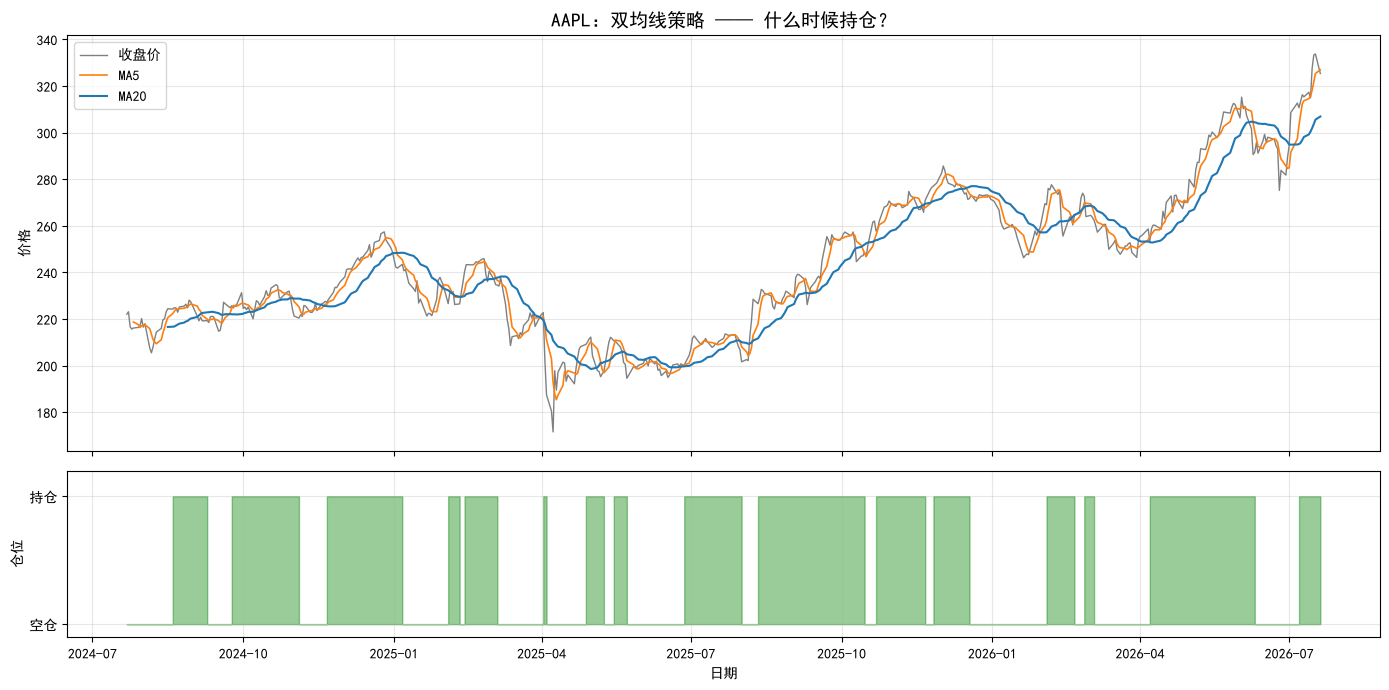

绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓


In [6]:
# ========== 价格+均线 + 持仓时间条 ==========
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,  # 创建子图
                         gridspec_kw={'height_ratios': [2.5, 1]})  # 子图高度比例

axes[0].plot(df.index, df['Close'], color='gray', linewidth=1, label='收盘价')  # 上图：画折线
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')  # 上图：画折线
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')  # 上图：画折线
axes[0].set_ylabel('价格')  # 设置上图纵轴
axes[0].set_title(f'{TICKER}：双均线策略 —— 什么时候持仓？', fontsize=14)  # 设置上图标题
axes[0].legend(loc='upper left')  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')  # 实际持仓（信号推迟一天）
axes[1].set_ylim(-0.1, 1.2)  # 执行本行代码
axes[1].set_yticks([0, 1])  # 执行本行代码
axes[1].set_yticklabels(['空仓', '持仓'])  # 执行本行代码
axes[1].set_xlabel('日期')  # 设置下图横轴（日期）
axes[1].set_ylabel('仓位')  # 设置下图纵轴
axes[1].grid(True, alpha=0.3)  # 下图显示网格

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('price_ma_position.png', dpi=150, bbox_inches='tight')  # 保存图片
plt.show()                               # 在 Notebook 里显示图片

print('绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓')  # 解读三色区域含义


In [7]:
# ========== 算日收益率 ==========
df['ret'] = df['Close'].pct_change().fillna(0)  # 股票本身每天涨跌

# ========== 策略收益：只有持仓日才吃到涨跌 ==========
df['strategy_ret'] = df['position'] * df['ret']  # 实际持仓（信号推迟一天）

# ========== 基准1：买入持有（一直满仓）==========
df['buyhold_ret'] = df['ret']  # 股票日收益率

# ========== 基准2：同期持有大盘 SPY ==========
# spy = yf.download(BENCHMARK, period=PERIOD, progress=False, multi_level_index=False)[['Close']]  # 下载股票日线行情
spy = pd.read_csv('spy_raw.csv', index_col=0, parse_dates=True)[['Close']]  # 读取本地已下载的大盘数据
spy.columns = ['SPY_Close']  # 重命名大盘收盘价列
df = df.join(spy, how='inner')  # 按日期对齐，只保留两边都有数据的行
df['market_ret'] = df['SPY_Close'].pct_change().fillna(0)  # 计算日收益率（今天相对昨天）

# ========== 累计净值：从 1 元钱出发连乘 ==========
df['nav_strategy'] = (1 + df['strategy_ret']).cumprod()  # 连乘得到累计净值/价格
df['nav_buyhold'] = (1 + df['buyhold_ret']).cumprod()  # 连乘得到累计净值/价格
df['nav_market'] = (1 + df['market_ret']).cumprod()  # 连乘得到累计净值/价格

total_strategy = df['nav_strategy'].iloc[-1] - 1  # 策略累计收益
total_buyhold = df['nav_buyhold'].iloc[-1] - 1  # 买入持有累计收益
total_market = df['nav_market'].iloc[-1] - 1  # 判断上交所 sh 还是深交所 sz

df.to_csv('backtest_nav.csv')  # 保存：含策略/买入持有/大盘净值的完整数据

print('=== 样本期累计收益（不含手续费，仅供学习）===')  # 打印分隔线或结论
print(f'  双均线策略 ({TICKER}): {total_strategy:+.2%}')  # 格式化打印
print(f'  买入持有 ({TICKER}):     {total_buyhold:+.2%}')  # 格式化打印
print(f'  买入持有 ({BENCHMARK} 大盘): {total_market:+.2%}')  # 格式化打印


=== 样本期累计收益（不含手续费，仅供学习）===
  双均线策略 (AAPL): -3.43%
  买入持有 (AAPL):     +46.53%
  买入持有 (SPY 大盘): +37.52%


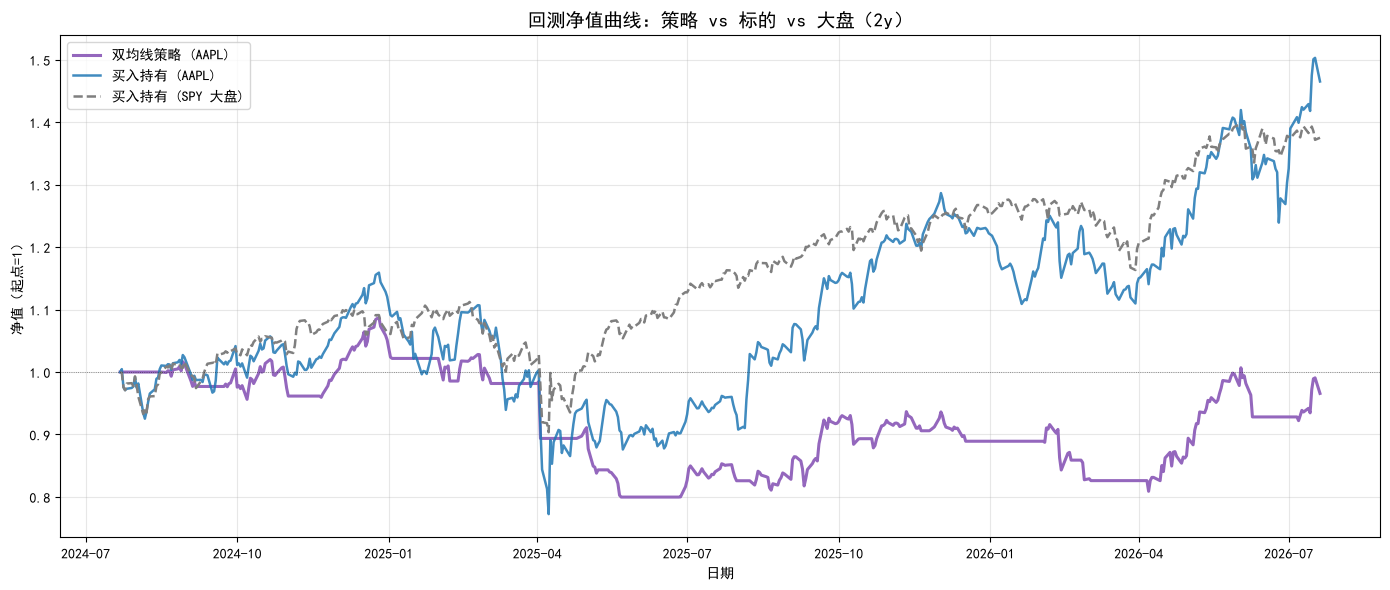

In [8]:
# ========== 三条净值曲线对比（回测高潮图）==========
fig, ax = plt.subplots(figsize=(14, 6))  # 创建子图

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',  # 在子图上画折线
        label=f'双均线策略 ({TICKER})')  # 图例文字
ax.plot(df.index, df['nav_buyhold'], linewidth=1.8, color='tab:blue', alpha=0.85,  # 在子图上画折线
        label=f'买入持有 ({TICKER})')  # 图例文字
ax.plot(df.index, df['nav_market'], linewidth=1.8, color='tab:gray', linestyle='--',  # 在子图上画折线
        label=f'买入持有 ({BENCHMARK} 大盘)')  # 图例文字

ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)  # 画水平参考线
ax.set_title(f'回测净值曲线：策略 vs 标的 vs 大盘（{PERIOD}）', fontsize=14)  # 设置子图标题
ax.set_xlabel('日期')  # 设置子图横轴
ax.set_ylabel('净值（起点=1）')  # 设置子图纵轴
ax.legend(loc='upper left')  # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('nav_comparison.png', dpi=150, bbox_inches='tight')

plt.show()                               # 在 Notebook 里显示图片


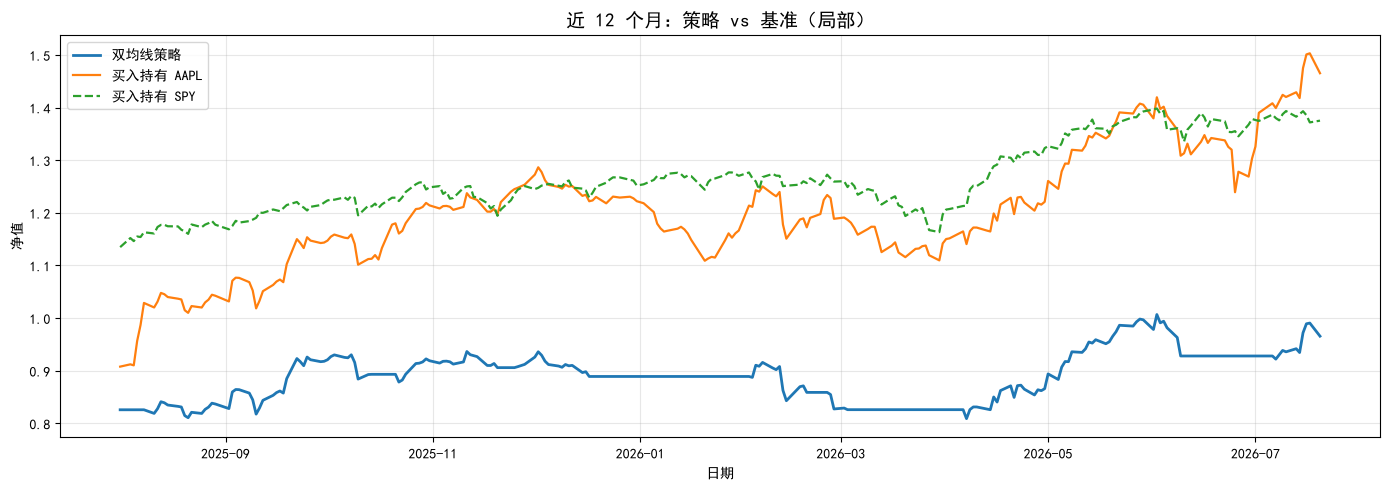

In [9]:
# ========== 近12个月局部放大 ==========
recent = df.last('12M') if len(df) > 200 else df.tail(200)  # 取最后若干行

plt.figure(figsize=(14, 5))  # 创建画布
plt.plot(recent.index, recent['nav_strategy'], linewidth=2, label='双均线策略')  # 画折线图
plt.plot(recent.index, recent['nav_buyhold'], linewidth=1.6, label=f'买入持有 {TICKER}')  # 画折线图
plt.plot(recent.index, recent['nav_market'], linewidth=1.6, linestyle='--', label=f'买入持有 {BENCHMARK}')  # 画折线图
plt.title('近 12 个月：策略 vs 基准（局部）', fontsize=14)  # 设置图标题
plt.xlabel('日期')  # 设置横轴标签
plt.ylabel('净值')  # 设置纵轴标签
plt.legend()  # 显示图例
plt.grid(True, alpha=0.3)  # 显示网格线
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('nav_recent_12m.png', dpi=150, bbox_inches='tight')

plt.show()                               # 在 Notebook 里显示图片


In [10]:
# ========== 统计胜率：一轮「买入→卖出」算一局 ==========
wins, losses = 0, 0       # 赢、输次数
entry_price = None        # 记住买入价
records = []              # 存每轮结果

for date, row in df.iterrows():  # 按天遍历整张表
    if row['action'] == '买入':  # 遇到买入日
        entry_price = row['Close']   # 记录买入当天的收盘价
    elif row['action'] == '卖出' and entry_price is not None:  # 遇到卖出且之前买过
        pnl = row['Close'] / entry_price - 1   # 本轮收益率
        if pnl > 0:  # 赚钱算赢
            wins += 1                    # 赢局计数 +1
            outcome = '赢'                 # 标记本局结果为赢
        else:  # 亏钱算输
            losses += 1                # 输局计数 +1
            outcome = '输'                 # 标记本局结果为输
        records.append({  # 记录本轮交易结果
            '卖出日': date.strftime('%Y-%m-%d'),  # 卖出日期
            '买入价': round(entry_price, 2),  # 买入价格
            '卖出价': round(row['Close'], 2),  # 卖出价格
            '本轮收益': f'{pnl:+.2%}',  # 本轮收益率
            '结果': outcome,  # 赢或输
        })  # 执行本行代码
        entry_price = None   # 本轮结束，清空买入价

total_rounds = wins + losses              # 完整买卖回合总数
win_rate = wins / total_rounds if total_rounds > 0 else np.nan  # 胜率

print(f'完整交易回合：{total_rounds} 轮')  # 打印回合总数
print(f'  赢：{wins} 次')  # 打印赢的次数
print(f'  输：{losses} 次')  # 打印输的次数
print(f'  胜率：{win_rate:.1%}' if total_rounds > 0 else '  暂无完整买卖回合')  # 打印胜率

if records:  # 有交易记录则展示
    display(pd.DataFrame(records).tail(8))  # 在 Notebook 中美观显示表格
    pd.DataFrame(records).to_csv('trade_rounds.csv', index=False)  # 保存：每轮买卖回合记录


完整交易回合：15 轮
  赢：5 次
  输：10 次
  胜率：33.3%


,卖出日,买入价,卖出价,本轮收益,结果
7,2025-05-23,210.61,194.50,-7.65%,输
8,2025-08-01,200.29,201.58,+0.65%,赢
9,2025-10-15,226.54,248.64,+9.75%,赢
10,2025-11-21,257.72,270.99,+5.15%,赢
11,2025-12-18,277.04,271.69,-1.93%,输
12,2026-02-20,268.98,264.34,-1.73%,输
13,2026-03-04,272.70,262.28,-3.82%,输
14,2026-06-10,253.27,291.58,+15.13%,赢


=== 最大回撤（样本期内最深一次「从山顶滑落」）===
  双均线策略: -26.46%
  买入持有 (AAPL): -33.36%


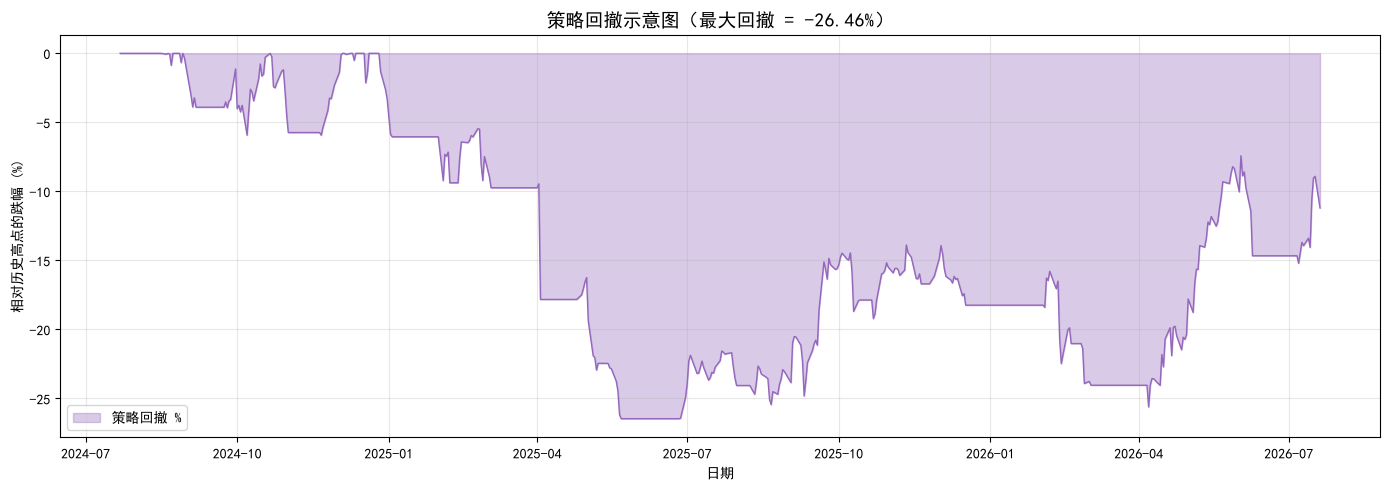

In [11]:
# ========== 最大回撤：从历史最高点最多跌了多少 ==========
def max_drawdown(nav_series):  # 定义最大回撤计算函数
    """输入净值序列，返回 (最大回撤比例, 每日回撤序列)。"""  # 字典字段
    peak = nav_series.cummax()           # 到每一天为止的历史最高净值
    drawdown = nav_series / peak - 1     # 当前净值相对峰值的跌幅
    return drawdown.min(), drawdown  # 返回最大回撤和回撤序列

mdd_strategy, dd_strategy = max_drawdown(df['nav_strategy'])  # 累计净值曲线
mdd_buyhold, dd_buyhold = max_drawdown(df['nav_buyhold'])  # 累计净值曲线

print('=== 最大回撤（样本期内最深一次「从山顶滑落」）===')  # 打印分隔线或结论
print(f'  双均线策略: {mdd_strategy:.2%}')  # 格式化打印
print(f'  买入持有 ({TICKER}): {mdd_buyhold:.2%}')  # 格式化打印

fig, ax = plt.subplots(figsize=(14, 5))  # 创建子图
ax.fill_between(df.index, dd_strategy * 100, 0, alpha=0.35, color='tab:purple', label='策略回撤 %')  # 在子图上填充区域
ax.plot(df.index, dd_strategy * 100, color='tab:purple', linewidth=1)  # 在子图上画折线
ax.set_title(f'策略回撤示意图（最大回撤 = {mdd_strategy:.2%}）', fontsize=14)  # 设置子图标题
ax.set_xlabel('日期')  # 设置子图横轴
ax.set_ylabel('相对历史高点的跌幅 (%)')  # 设置子图纵轴
ax.legend()                                    # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('drawdown.png', dpi=150, bbox_inches='tight')

plt.show()                               # 在 Notebook 里显示图片


In [ ]:
挑战1：

In [12]:
# ========== 环境准备 ==========
import warnings                          # 导入警告控制模块
warnings.filterwarnings('ignore')        # 隐藏不影响学习的警告

import numpy as np                       # 数值计算（数组、随机数、统计）
import pandas as pd                      # 表格数据处理（像 Excel）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）
import yfinance as yf                    # 从雅虎财经下载行情（需联网）

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

TICKER = 'NVDA'      # 策略交易哪只股票
BENCHMARK = 'SPY'    # 大盘对比用标普500 ETF
PERIOD = '2y'        # 回测样本长度

print('环境就绪 ✓')                       # 提示：环境加载完成


环境就绪 ✓


In [13]:
# ========== 第1步：读取本地数据并算双均线 ==========
raw = pd.read_csv('nvda_2y_raw.csv', index_col=0, parse_dates=True)  # 读取本地已下载的行情数据
df = raw[['Close']].dropna().copy()
df.columns = ['Close']

df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['signal'] = (df['MA5'] > df['MA20']).astype(int)

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)
df['action'] = ''
df.loc[df['position_change'] > 0, 'action'] = '买入'
df.loc[df['position_change'] < 0, 'action'] = '卖出'

trades = df[df['action'] != '']
print(f'标的 {TICKER}，共 {len(df)} 个交易日')
print(f'模拟交易：买入 { (df["action"]=="买入").sum() } 次，卖出 { (df["action"]=="卖出").sum() } 次')
print('\n最近几次调仓：')
display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))

df.to_csv('backtest_data_nvda.csv')  # 保存：含仓位/买卖标记的数据

标的 NVDA，共 500 个交易日
模拟交易：买入 20 次，卖出 19 次

最近几次调仓：


,Close,MA5,MA20,position,action
Date,,,,,
2026-03-04,182.817017,181.308859,185.181139,0,卖出
2026-04-09,183.695908,179.614661,176.939777,1,买入
2026-05-07,211.253784,202.316199,201.618015,0,卖出
2026-05-08,214.949478,205.662299,202.944968,1,买入
2026-06-01,224.098816,215.191199,216.501171,0,卖出
2026-07-13,203.529999,203.663998,201.884499,1,买入


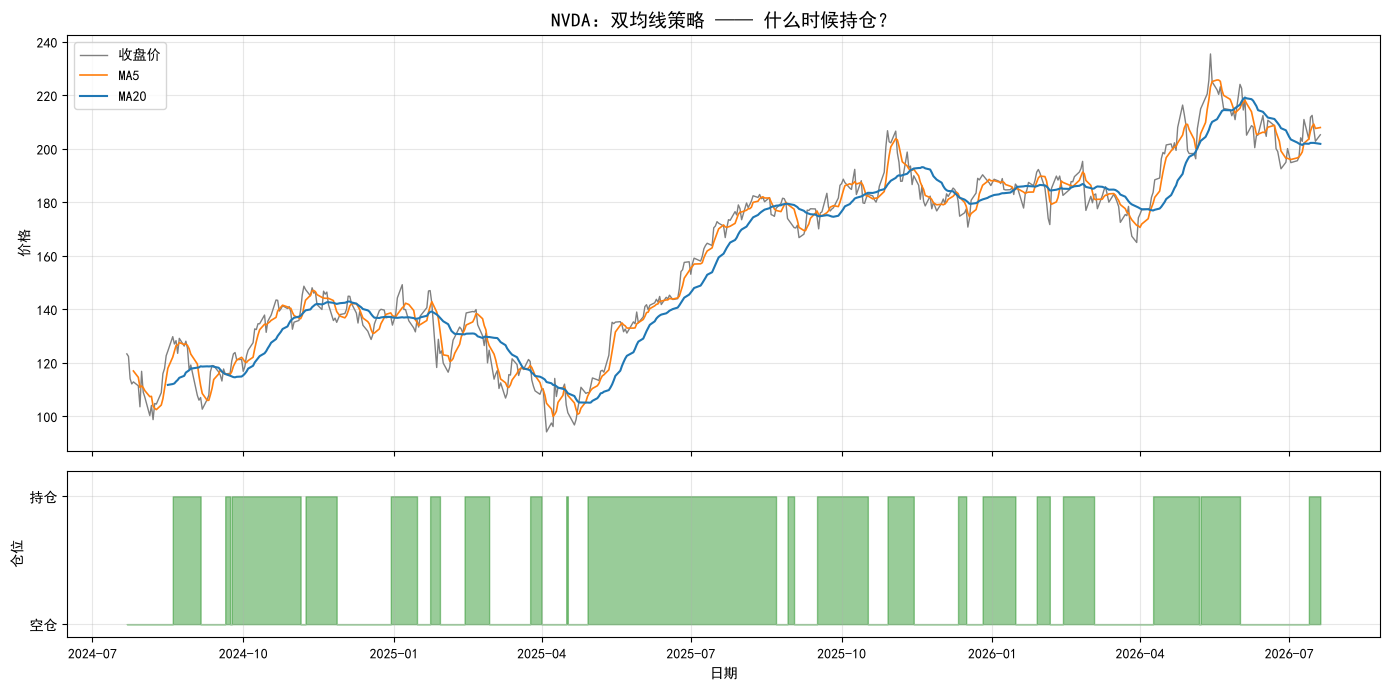

绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓


In [14]:
# ========== 价格+均线 + 持仓时间条 ==========
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1]})

axes[0].plot(df.index, df['Close'], color='gray', linewidth=1, label='收盘价')
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')
axes[0].set_ylabel('价格')
axes[0].set_title(f'{TICKER}：双均线策略 —— 什么时候持仓？', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['空仓', '持仓'])
axes[1].set_xlabel('日期')
axes[1].set_ylabel('仓位')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_ma_position_nvda.png', dpi=150, bbox_inches='tight')  # 保存图片
plt.show()

print('绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓')

In [15]:
# ========== 算日收益率 ==========
df['ret'] = df['Close'].pct_change().fillna(0)

# ========== 策略收益：只有持仓日才吃到涨跌 ==========
df['strategy_ret'] = df['position'] * df['ret']

# ========== 基准1：买入持有（一直满仓）==========
df['buyhold_ret'] = df['ret']

# ========== 基准2：同期持有大盘 SPY ==========
spy = pd.read_csv('spy_raw.csv', index_col=0, parse_dates=True)[['Close']]  # 读取本地已下载的大盘数据
spy.columns = ['SPY_Close']
df = df.join(spy, how='inner')
df['market_ret'] = df['SPY_Close'].pct_change().fillna(0)

# ========== 累计净值：从 1 元钱出发连乘 ==========
df['nav_strategy'] = (1 + df['strategy_ret']).cumprod()
df['nav_buyhold'] = (1 + df['buyhold_ret']).cumprod()
df['nav_market'] = (1 + df['market_ret']).cumprod()

total_strategy = df['nav_strategy'].iloc[-1] - 1
total_buyhold = df['nav_buyhold'].iloc[-1] - 1
total_market = df['nav_market'].iloc[-1] - 1

print('=== 样本期累计收益（不含手续费，仅供学习）===')
print(f'  双均线策略 ({TICKER}): {total_strategy:+.2%}')
print(f'  买入持有 ({TICKER}):     {total_buyhold:+.2%}')
print(f'  买入持有 ({BENCHMARK} 大盘): {total_market:+.2%}')

df.to_csv('backtest_nav_nvda.csv')  # 保存：含策略/买入持有/大盘净值的完整数据

=== 样本期累计收益（不含手续费，仅供学习）===
  双均线策略 (NVDA): -21.14%
  买入持有 (NVDA):     +66.42%
  买入持有 (SPY 大盘): +37.52%


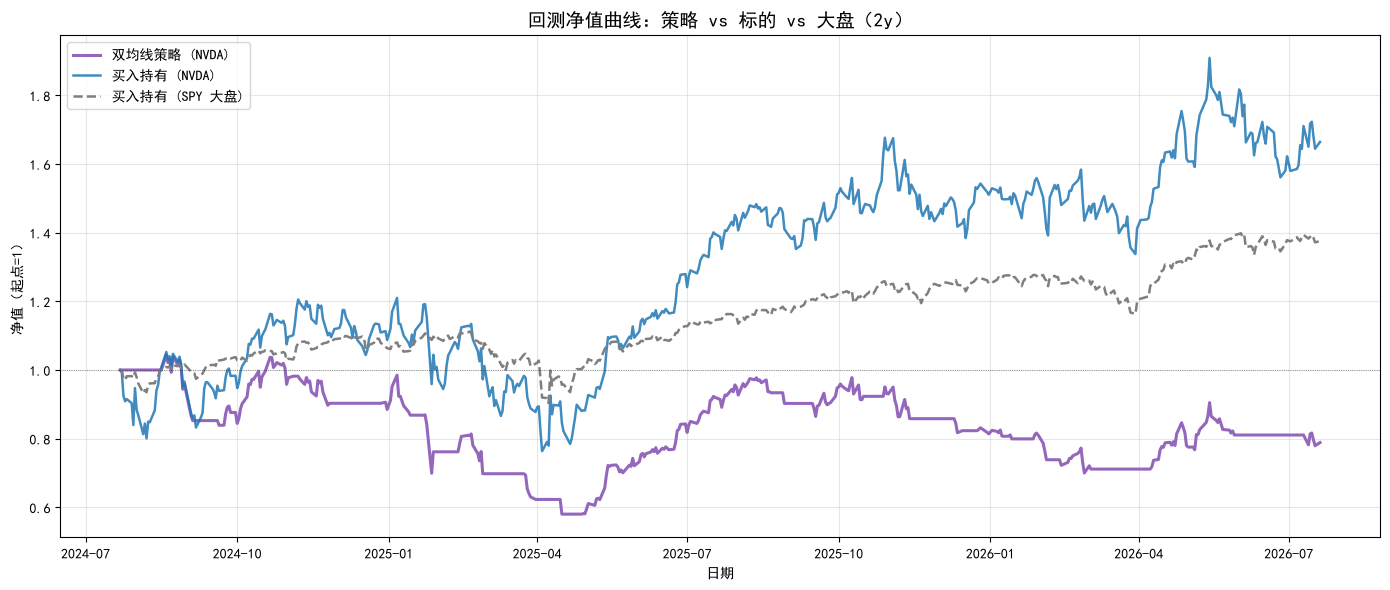

In [16]:
# ========== 三条净值曲线对比（回测高潮图）==========
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',
        label=f'双均线策略 ({TICKER})')
ax.plot(df.index, df['nav_buyhold'], linewidth=1.8, color='tab:blue', alpha=0.85,
        label=f'买入持有 ({TICKER})')
ax.plot(df.index, df['nav_market'], linewidth=1.8, color='tab:gray', linestyle='--',
        label=f'买入持有 ({BENCHMARK} 大盘)')

ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_title(f'回测净值曲线：策略 vs 标的 vs 大盘（{PERIOD}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('净值（起点=1）')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nav_comparison_nvda.png', dpi=150, bbox_inches='tight')  # 保存图片
plt.show()


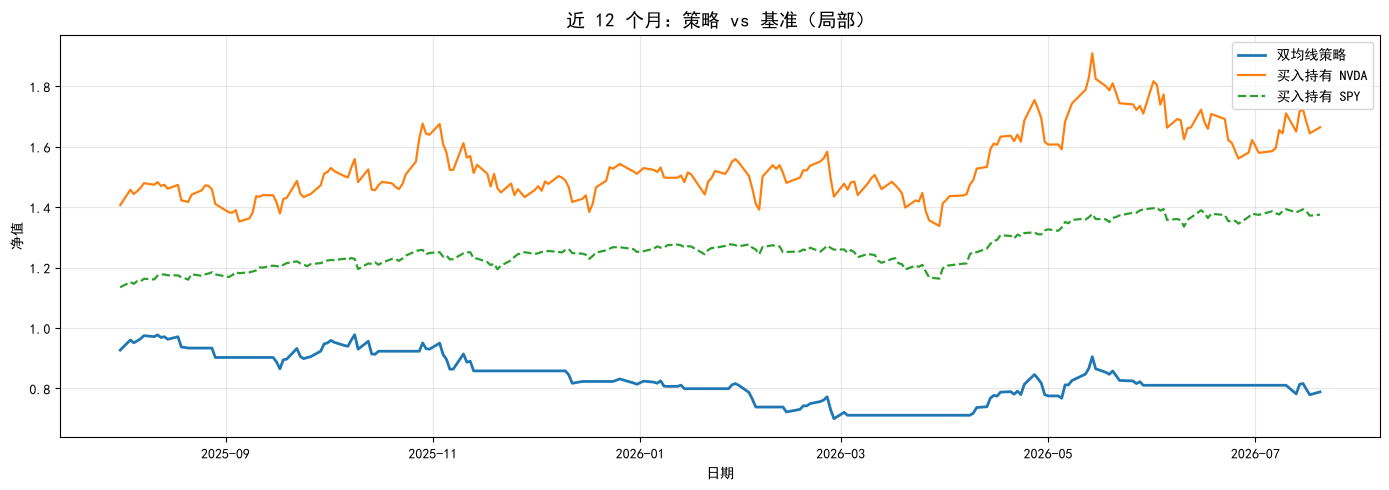

In [17]:
recent = df.last('12M') if len(df) > 200 else df.tail(200)

plt.figure(figsize=(14, 5))
plt.plot(recent.index, recent['nav_strategy'], linewidth=2, label='双均线策略')
plt.plot(recent.index, recent['nav_buyhold'], linewidth=1.6, label=f'买入持有 {TICKER}')
plt.plot(recent.index, recent['nav_market'], linewidth=1.6, linestyle='--', label=f'买入持有 {BENCHMARK}')
plt.title('近 12 个月：策略 vs 基准（局部）', fontsize=14)
plt.xlabel('日期')
plt.ylabel('净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nav_recent_12m_nvda.png', dpi=150, bbox_inches='tight')  # 保存图片
plt.show()

In [18]:
# ========== 统计胜率：一轮「买入→卖出」算一局 ==========
wins, losses = 0, 0
entry_price = None
records = []

for date, row in df.iterrows():
    if row['action'] == '买入':
        entry_price = row['Close']
    elif row['action'] == '卖出' and entry_price is not None:
        pnl = row['Close'] / entry_price - 1
        if pnl > 0:
            wins += 1
            outcome = '赢'
        else:
            losses += 1
            outcome = '输'
        records.append({
            '卖出日': date.strftime('%Y-%m-%d'),
            '买入价': round(entry_price, 2),
            '卖出价': round(row['Close'], 2),
            '本轮收益': f'{pnl:+.2%}',
            '结果': outcome,
        })
        entry_price = None

total_rounds = wins + losses
win_rate = wins / total_rounds if total_rounds > 0 else np.nan

print(f'完整交易回合：{total_rounds} 轮')
print(f'  赢：{wins} 次')
print(f'  输：{losses} 次')
print(f'  胜率：{win_rate:.1%}' if total_rounds > 0 else '  暂无完整买卖回合')

if records:
    display(pd.DataFrame(records).tail(8))
    pd.DataFrame(records).to_csv('trade_rounds_nvda.csv', index=False)  # 保存：每轮买卖回合记录


完整交易回合：19 轮
  赢：7 次
  输：12 次
  胜率：36.8%


,卖出日,买入价,卖出价,本轮收益,结果
11,2025-10-17,174.66,182.99,+4.77%,赢
12,2025-11-14,206.78,189.93,-8.15%,输
13,2025-12-16,180.71,177.50,-1.77%,输
14,2026-01-15,190.30,186.82,-1.83%,输
15,2026-02-05,191.29,171.67,-10.25%,输
16,2026-03-04,182.59,182.82,+0.13%,赢
17,2026-05-07,183.70,211.25,+15.00%,赢
18,2026-06-01,214.95,224.10,+4.26%,赢


=== 最大回撤（样本期内最深一次「从山顶滑落」）===
  双均线策略: -44.41%
  买入持有 (NVDA): -36.88%


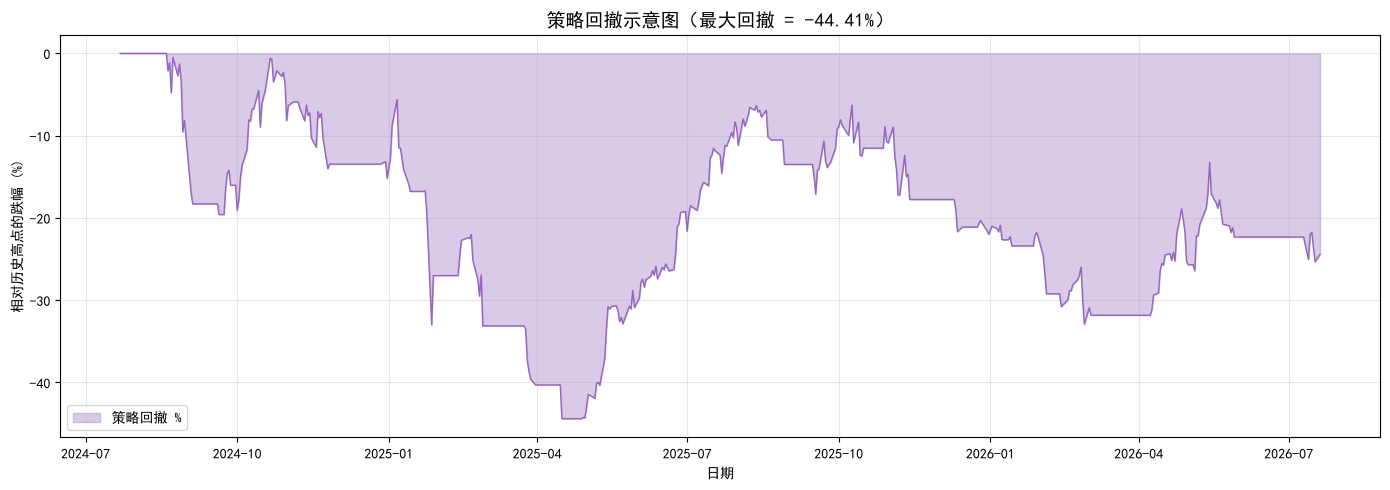

In [19]:
# ========== 最大回撤：从历史最高点最多跌了多少 ==========
def max_drawdown(nav_series):
    """输入净值序列，返回 (最大回撤比例, 每日回撤序列)。"""
    peak = nav_series.cummax()
    drawdown = nav_series / peak - 1
    return drawdown.min(), drawdown

mdd_strategy, dd_strategy = max_drawdown(df['nav_strategy'])
mdd_buyhold, dd_buyhold = max_drawdown(df['nav_buyhold'])

print('=== 最大回撤（样本期内最深一次「从山顶滑落」）===')
print(f'  双均线策略: {mdd_strategy:.2%}')
print(f'  买入持有 ({TICKER}): {mdd_buyhold:.2%}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, dd_strategy * 100, 0, alpha=0.35, color='tab:purple', label='策略回撤 %')
ax.plot(df.index, dd_strategy * 100, color='tab:purple', linewidth=1)
ax.set_title(f'策略回撤示意图（最大回撤 = {mdd_strategy:.2%}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('相对历史高点的跌幅 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown_nvda.png', dpi=150, bbox_inches='tight')  # 保存图片
plt.show()

In [ ]:
挑战2.1y：

In [20]:
# ========== 环境准备 ==========
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

TICKER = 'NVDA'
BENCHMARK = 'SPY'
PERIOD = '1y'

print('环境就绪 ✓')


环境就绪 ✓


In [21]:
# ========== 第1步：读取本地数据并算双均线 ==========
raw = pd.read_csv('nvda_1y_raw.csv', index_col=0, parse_dates=True)
df = raw[['Close']].dropna().copy()
df.columns = ['Close']

df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['signal'] = (df['MA5'] > df['MA20']).astype(int)

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)
df['action'] = ''
df.loc[df['position_change'] > 0, 'action'] = '买入'
df.loc[df['position_change'] < 0, 'action'] = '卖出'

trades = df[df['action'] != '']
print(f'标的 {TICKER}，共 {len(df)} 个交易日')
print(f'模拟交易：买入 { (df["action"]=="买入").sum() } 次，卖出 { (df["action"]=="卖出").sum() } 次')
print('\n最近几次调仓：')
display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))

df.to_csv('backtest_data_nvda_1y.csv')


标的 NVDA，共 251 个交易日
模拟交易：买入 11 次，卖出 10 次

最近几次调仓：


,Close,MA5,MA20,position,action
Date,,,,,
2026-03-04,182.817017,181.308859,185.181138,0,卖出
2026-04-09,183.695908,179.614661,176.939777,1,买入
2026-05-07,211.253784,202.316199,201.618015,0,卖出
2026-05-08,214.949478,205.662299,202.944968,1,买入
2026-06-01,224.098816,215.191199,216.501171,0,卖出
2026-07-13,203.529999,203.663998,201.884499,1,买入


In [22]:
df['ret'] = df['Close'].pct_change().fillna(0)
df['strategy_ret'] = df['position'] * df['ret']
df['buyhold_ret'] = df['ret']

spy = pd.read_csv('spy_1y_raw.csv', index_col=0, parse_dates=True)[['Close']]
spy.columns = ['SPY_Close']
df = df.join(spy, how='inner')
df['market_ret'] = df['SPY_Close'].pct_change().fillna(0)

df['nav_strategy'] = (1 + df['strategy_ret']).cumprod()
df['nav_buyhold'] = (1 + df['buyhold_ret']).cumprod()
df['nav_market'] = (1 + df['market_ret']).cumprod()

total_strategy = df['nav_strategy'].iloc[-1] - 1
total_buyhold = df['nav_buyhold'].iloc[-1] - 1
total_market = df['nav_market'].iloc[-1] - 1

print('=== 样本期累计收益（不含手续费，仅供学习）===')
print(f'  双均线策略 ({TICKER}): {total_strategy:+.2%}')
print(f'  买入持有 ({TICKER}):     {total_buyhold:+.2%}')
print(f'  买入持有 ({BENCHMARK} 大盘): {total_market:+.2%}')

df.to_csv('backtest_nav_nvda_1y.csv')


=== 样本期累计收益（不含手续费，仅供学习）===
  双均线策略 (NVDA): -18.09%
  买入持有 (NVDA):     +19.93%
  买入持有 (SPY 大盘): +20.03%


=== 最大回撤（样本期内最深一次「从山顶滑落」）===
  双均线策略: -28.41%
  买入持有 (NVDA): -20.21%


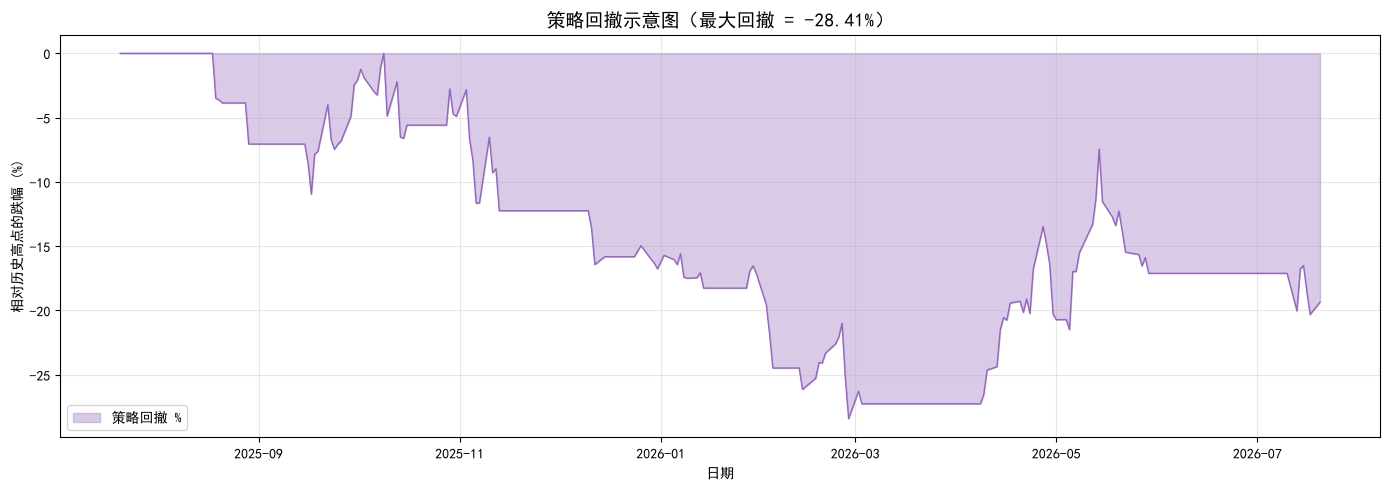

In [23]:
# ========== 最大回撤 ==========
def max_drawdown(nav_series):
    """输入净值序列，返回 (最大回撤比例, 每日回撤序列)。"""
    peak = nav_series.cummax()
    drawdown = nav_series / peak - 1
    return drawdown.min(), drawdown

mdd_strategy, dd_strategy = max_drawdown(df['nav_strategy'])
mdd_buyhold, dd_buyhold = max_drawdown(df['nav_buyhold'])

print('=== 最大回撤（样本期内最深一次「从山顶滑落」）===')
print(f'  双均线策略: {mdd_strategy:.2%}')
print(f'  买入持有 ({TICKER}): {mdd_buyhold:.2%}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, dd_strategy * 100, 0, alpha=0.35, color='tab:purple', label='策略回撤 %')
ax.plot(df.index, dd_strategy * 100, color='tab:purple', linewidth=1)
ax.set_title(f'策略回撤示意图（最大回撤 = {mdd_strategy:.2%}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('相对历史高点的跌幅 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown_nvda_1y.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
挑战2.5y：

In [24]:
# ========== 环境准备 ==========
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

TICKER = 'NVDA'
BENCHMARK = 'SPY'
PERIOD = '5y'

print('环境就绪 ✓')


环境就绪 ✓


In [25]:
# ========== 第1步：读取本地数据并算双均线 ==========
raw = pd.read_csv('nvda_5y_raw.csv', index_col=0, parse_dates=True)
df = raw[['Close']].dropna().copy()
df.columns = ['Close']

df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['signal'] = (df['MA5'] > df['MA20']).astype(int)

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)
df['action'] = ''
df.loc[df['position_change'] > 0, 'action'] = '买入'
df.loc[df['position_change'] < 0, 'action'] = '卖出'

trades = df[df['action'] != '']
print(f'标的 {TICKER}，共 {len(df)} 个交易日')
print(f'模拟交易：买入 { (df["action"]=="买入").sum() } 次，卖出 { (df["action"]=="卖出").sum() } 次')
print('\n最近几次调仓：')
display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))

df.to_csv('backtest_data_nvda_5y.csv')

标的 NVDA，共 1255 个交易日
模拟交易：买入 40 次，卖出 39 次

最近几次调仓：


,Close,MA5,MA20,position,action
Date,,,,,
2026-03-04,182.817017,181.308859,185.181138,0,卖出
2026-04-09,183.695908,179.614661,176.939777,1,买入
2026-05-07,211.253784,202.316199,201.618015,0,卖出
2026-05-08,214.949478,205.662299,202.944968,1,买入
2026-06-01,224.098816,215.191199,216.501171,0,卖出
2026-07-13,203.529999,203.663998,201.884499,1,买入


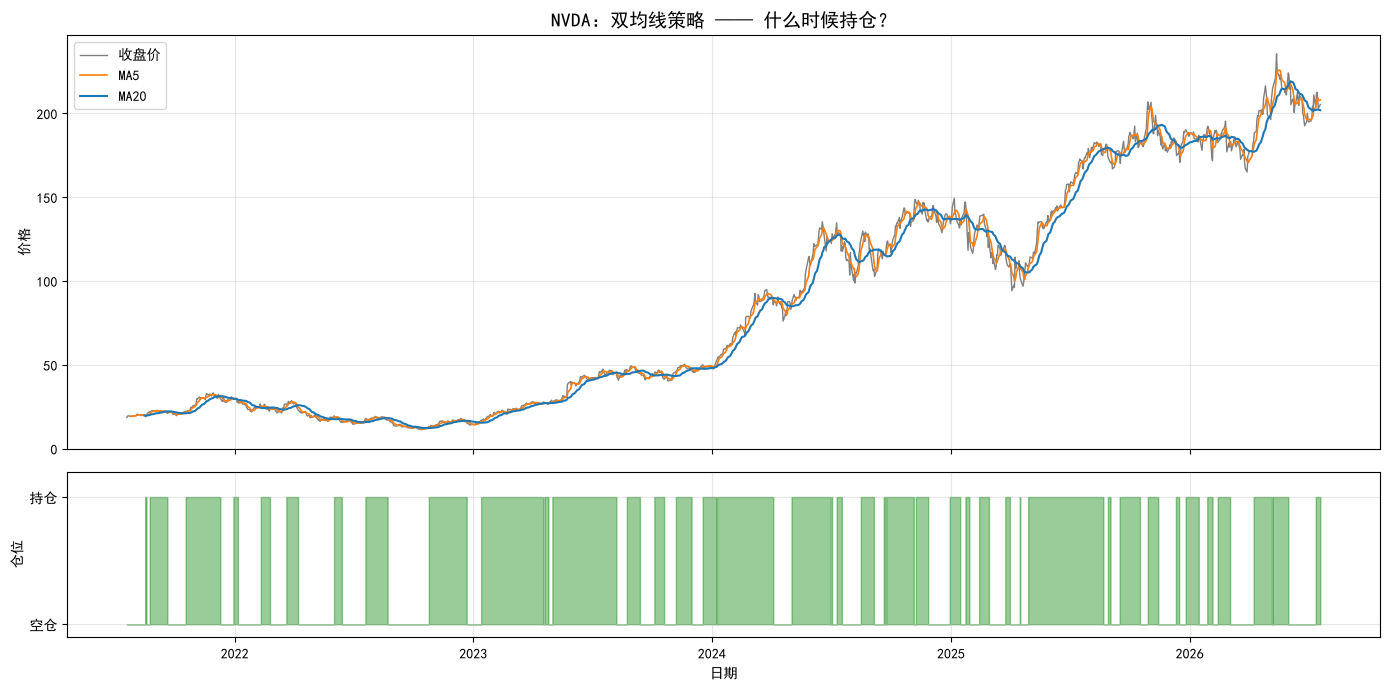

绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓


In [26]:
# ========== 价格+均线 + 持仓时间条 ==========
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1]})

axes[0].plot(df.index, df['Close'], color='gray', linewidth=1, label='收盘价')
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')
axes[0].set_ylabel('价格')
axes[0].set_title(f'{TICKER}：双均线策略 —— 什么时候持仓？', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['空仓', '持仓'])
axes[1].set_xlabel('日期')
axes[1].set_ylabel('仓位')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_ma_position_nvda_5y.png', dpi=150, bbox_inches='tight')
plt.show()

print('绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓')


In [27]:
# ========== 算日收益率 ==========
df['ret'] = df['Close'].pct_change().fillna(0)

# ========== 策略收益：只有持仓日才吃到涨跌 ==========
df['strategy_ret'] = df['position'] * df['ret']

# ========== 基准1：买入持有（一直满仓）==========
df['buyhold_ret'] = df['ret']

# ========== 基准2：同期持有大盘 SPY ==========
spy = pd.read_csv('spy_5y_raw.csv', index_col=0, parse_dates=True)[['Close']]
spy.columns = ['SPY_Close']
df = df.join(spy, how='inner')
df['market_ret'] = df['SPY_Close'].pct_change().fillna(0)

# ========== 累计净值：从 1 元钱出发连乘 ==========
df['nav_strategy'] = (1 + df['strategy_ret']).cumprod()
df['nav_buyhold'] = (1 + df['buyhold_ret']).cumprod()
df['nav_market'] = (1 + df['market_ret']).cumprod()

total_strategy = df['nav_strategy'].iloc[-1] - 1
total_buyhold = df['nav_buyhold'].iloc[-1] - 1
total_market = df['nav_market'].iloc[-1] - 1

print('=== 样本期累计收益（不含手续费，仅供学习）===')
print(f'  双均线策略 ({TICKER}): {total_strategy:+.2%}')
print(f'  买入持有 ({TICKER}):     {total_buyhold:+.2%}')
print(f'  买入持有 ({BENCHMARK} 大盘): {total_market:+.2%}')

df.to_csv('backtest_nav_nvda_5y.csv')

=== 样本期累计收益（不含手续费，仅供学习）===
  双均线策略 (NVDA): +326.07%
  买入持有 (NVDA):     +1006.68%
  买入持有 (SPY 大盘): +85.26%


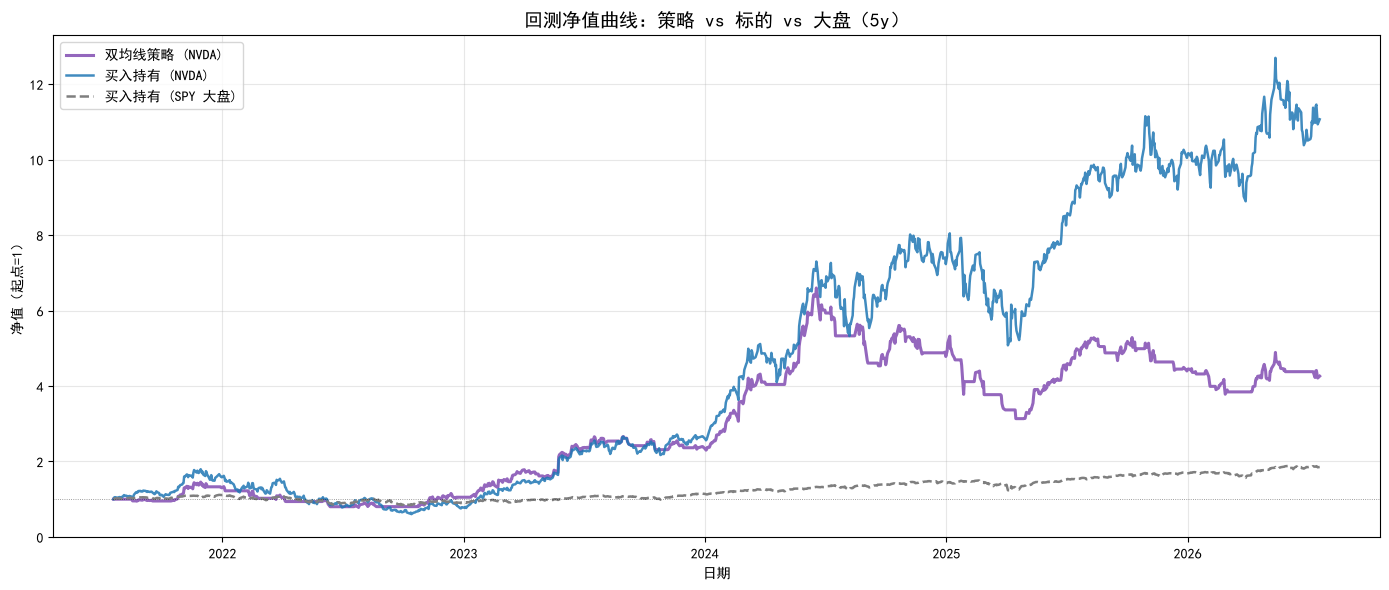

In [28]:
# ========== 三条净值曲线对比（回测高潮图）==========
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',
        label=f'双均线策略 ({TICKER})')
ax.plot(df.index, df['nav_buyhold'], linewidth=1.8, color='tab:blue', alpha=0.85,
        label=f'买入持有 ({TICKER})')
ax.plot(df.index, df['nav_market'], linewidth=1.8, color='tab:gray', linestyle='--',
        label=f'买入持有 ({BENCHMARK} 大盘)')

ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_title(f'回测净值曲线：策略 vs 标的 vs 大盘（{PERIOD}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('净值（起点=1）')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nav_comparison_nvda_5y.png', dpi=150, bbox_inches='tight')
plt.show()


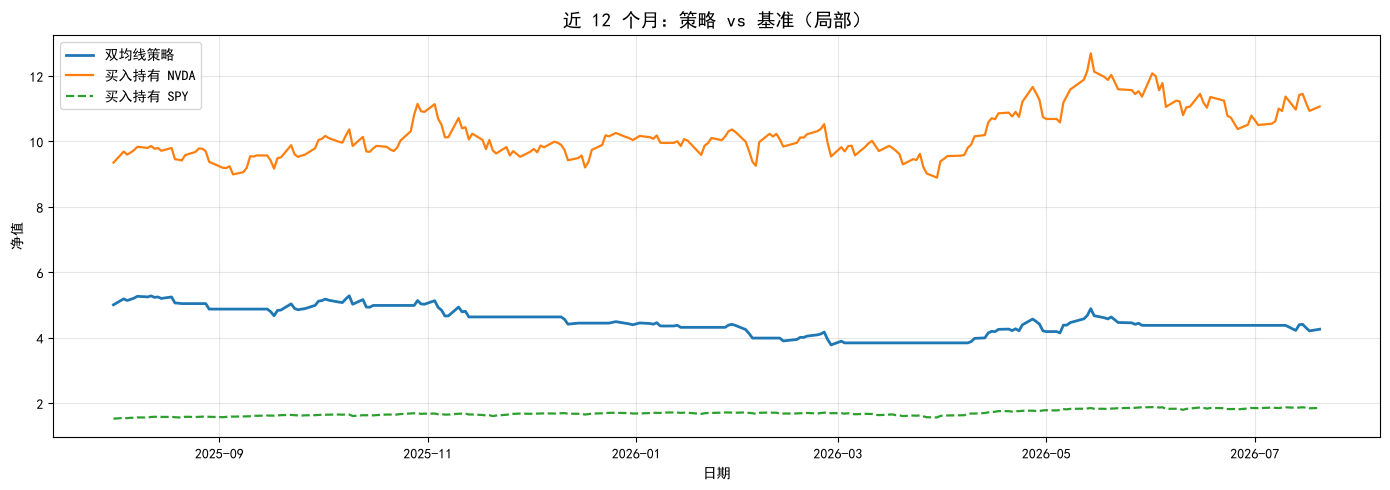

In [29]:
# ========== 近12个月局部放大 ==========
recent = df.last('12M') if len(df) > 200 else df.tail(200)

plt.figure(figsize=(14, 5))
plt.plot(recent.index, recent['nav_strategy'], linewidth=2, label='双均线策略')
plt.plot(recent.index, recent['nav_buyhold'], linewidth=1.6, label=f'买入持有 {TICKER}')
plt.plot(recent.index, recent['nav_market'], linewidth=1.6, linestyle='--', label=f'买入持有 {BENCHMARK}')
plt.title('近 12 个月：策略 vs 基准（局部）', fontsize=14)
plt.xlabel('日期')
plt.ylabel('净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nav_recent_12m_nvda_5y.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# ========== 统计胜率：一轮「买入→卖出」算一局 ==========
wins, losses = 0, 0
entry_price = None
records = []

for date, row in df.iterrows():
    if row['action'] == '买入':
        entry_price = row['Close']
    elif row['action'] == '卖出' and entry_price is not None:
        pnl = row['Close'] / entry_price - 1
        if pnl > 0:
            wins += 1
            outcome = '赢'
        else:
            losses += 1
            outcome = '输'
        records.append({
            '卖出日': date.strftime('%Y-%m-%d'),
            '买入价': round(entry_price, 2),
            '卖出价': round(row['Close'], 2),
            '本轮收益': f'{pnl:+.2%}',
            '结果': outcome,
        })
        entry_price = None

total_rounds = wins + losses
win_rate = wins / total_rounds if total_rounds > 0 else np.nan

print(f'完整交易回合：{total_rounds} 轮')
print(f'  赢：{wins} 次')
print(f'  输：{losses} 次')
print(f'  胜率：{win_rate:.1%}' if total_rounds > 0 else '  暂无完整买卖回合')

if records:
    display(pd.DataFrame(records).tail(8))
    pd.DataFrame(records).to_csv('trade_rounds_nvda_5y.csv', index=False)

完整交易回合：39 轮
  赢：17 次
  输：22 次
  胜率：43.6%


,卖出日,买入价,卖出价,本轮收益,结果
31,2025-10-17,174.66,182.99,+4.77%,赢
32,2025-11-14,206.78,189.93,-8.15%,输
33,2025-12-16,180.71,177.50,-1.77%,输
34,2026-01-15,190.30,186.82,-1.83%,输
35,2026-02-05,191.29,171.67,-10.25%,输
36,2026-03-04,182.59,182.82,+0.13%,赢
37,2026-05-07,183.70,211.25,+15.00%,赢
38,2026-06-01,214.95,224.10,+4.26%,赢


=== 最大回撤（样本期内最深一次「从山顶滑落」）===
  双均线策略: -52.50%
  买入持有 (NVDA): -66.34%


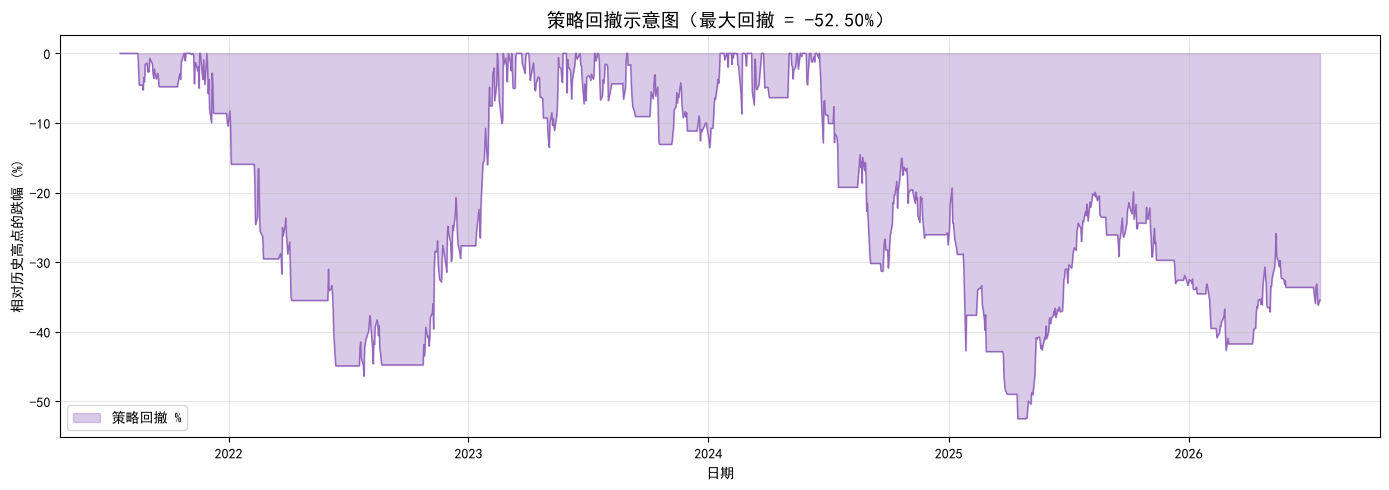

In [31]:
# ========== 最大回撤：从历史最高点最多跌了多少 ==========
def max_drawdown(nav_series):
    """输入净值序列，返回 (最大回撤比例, 每日回撤序列)。"""
    peak = nav_series.cummax()
    drawdown = nav_series / peak - 1
    return drawdown.min(), drawdown

mdd_strategy, dd_strategy = max_drawdown(df['nav_strategy'])
mdd_buyhold, dd_buyhold = max_drawdown(df['nav_buyhold'])

print('=== 最大回撤（样本期内最深一次「从山顶滑落」）===')
print(f'  双均线策略: {mdd_strategy:.2%}')
print(f'  买入持有 ({TICKER}): {mdd_buyhold:.2%}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, dd_strategy * 100, 0, alpha=0.35, color='tab:purple', label='策略回撤 %')
ax.plot(df.index, dd_strategy * 100, color='tab:purple', linewidth=1)
ax.set_title(f'策略回撤示意图（最大回撤 = {mdd_strategy:.2%}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('相对历史高点的跌幅 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown_nvda_5y.png', dpi=150, bbox_inches='tight')
plt.show()